In [3]:
import json
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import Dataset, DataLoader, random_split
from transformers import AutoTokenizer, AutoModel, pipeline
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: NVIDIA A100 80GB PCIe MIG 1g.10gb


In [4]:
data_dir = Path('/gpfs/home/smaccall/earnings-call-prediction/notebooks/data/transcripts')

def flatten_transcript(data):
    """Join speaker turns into single string."""
    if isinstance(data['transcript'], list):
        return ' '.join([turn['content'] for turn in data['transcript']])
    return data['transcript']

records = []
for path in data_dir.glob('*.json'):
    with open(path) as f:
        data = json.load(f)
    if 'transcript' in data and 'return_pct' in data:
        data['transcript'] = flatten_transcript(data)
        records.append(data)

print(f'Loaded {len(records)} transcripts')
print(f'Example: {records[0]["symbol"]} {records[0]["quarter"]} -> {records[0]["return_pct"]:.2f}%')

Loaded 148 transcripts
Example: GS 2022Q3 -> -0.06%


In [5]:
tokenizer = AutoTokenizer.from_pretrained('ProsusAI/finbert')

class EarningsDataset(Dataset):
    def __init__(self, records, tokenizer, max_length=512):
        self.records = records
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.records)
    
    def __getitem__(self, idx):
        record = self.records[idx]
        encoding = self.tokenizer(
            record['transcript'],
            max_length=self.max_length,
            truncation=True,
            padding='max_length',
            return_tensors='pt'
        )
        return {
    'input_ids': encoding['input_ids'].squeeze(0),
    'attention_mask': encoding['attention_mask'].squeeze(0),
    'label': torch.tensor(record['return_pct'], dtype=torch.float),
    'symbol': record.get('symbol', ''),
    'quarter': record.get('quarter', ''),
}

dataset = EarningsDataset(records, tokenizer)
print(f'Dataset size: {len(dataset)}')

Dataset size: 148


In [6]:
class EarningsModel(nn.Module):
    """
    FinBERT fine-tuned for return regression.
    Takes transcript text -> predicts post-earnings return %
    """
    def __init__(self):
        super().__init__()
        self.bert = AutoModel.from_pretrained('ProsusAI/finbert')
        self.dropout = nn.Dropout(0.1)
        self.regressor = nn.Linear(768, 1)
    
    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls = outputs.last_hidden_state[:, 0, :]
        cls = self.dropout(cls)
        return self.regressor(cls).squeeze(-1)

model = EarningsModel().to(device)
print(f'Model loaded on {device}')
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Model loaded on cuda
Parameters: 109,483,009


In [7]:
# 80/20 split
n_test = max(1, int(len(dataset) * 0.2))
n_train = len(dataset) - n_test
train_ds, test_ds = random_split(dataset, [n_train, n_test])

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=8)

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
criterion = nn.MSELoss()

print(f'Train: {n_train} | Test: {n_test}')

Train: 119 | Test: 29


In [8]:
train_losses = []
val_rmses = []
dir_accs = []

EPOCHS = 5

for epoch in range(EPOCHS):
    # Train
    model.train()
    total_loss = 0
    for batch in train_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        optimizer.zero_grad()
        preds = model(input_ids, attention_mask)
        loss = criterion(preds, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    
    # Eval
    model.eval()
    val_loss = 0
    correct = 0
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            preds = model(input_ids, attention_mask)
            val_loss += criterion(preds, labels).item()
            correct += ((preds >= 0) == (labels >= 0)).sum().item()
    
    train_losses.append(total_loss / len(train_loader))
    val_rmses.append((val_loss / len(test_loader)) ** 0.5)
    dir_accs.append(correct / n_test)
    print(f'Epoch {epoch+1}/{EPOCHS} | Loss: {train_losses[-1]:.4f} | RMSE: {val_rmses[-1]:.4f} | Dir Acc: {dir_accs[-1]:.2f}')

torch.save(model.state_dict(), 'best_model.pt')
print('Model saved!')

Epoch 1/5 | Loss: 15.4853 | RMSE: 5.6359 | Dir Acc: 0.41
Epoch 2/5 | Loss: 14.6265 | RMSE: 5.6393 | Dir Acc: 0.38
Epoch 3/5 | Loss: 13.8948 | RMSE: 5.6822 | Dir Acc: 0.31
Epoch 4/5 | Loss: 12.5674 | RMSE: 5.9479 | Dir Acc: 0.31
Epoch 5/5 | Loss: 11.4958 | RMSE: 5.8629 | Dir Acc: 0.34
Model saved!


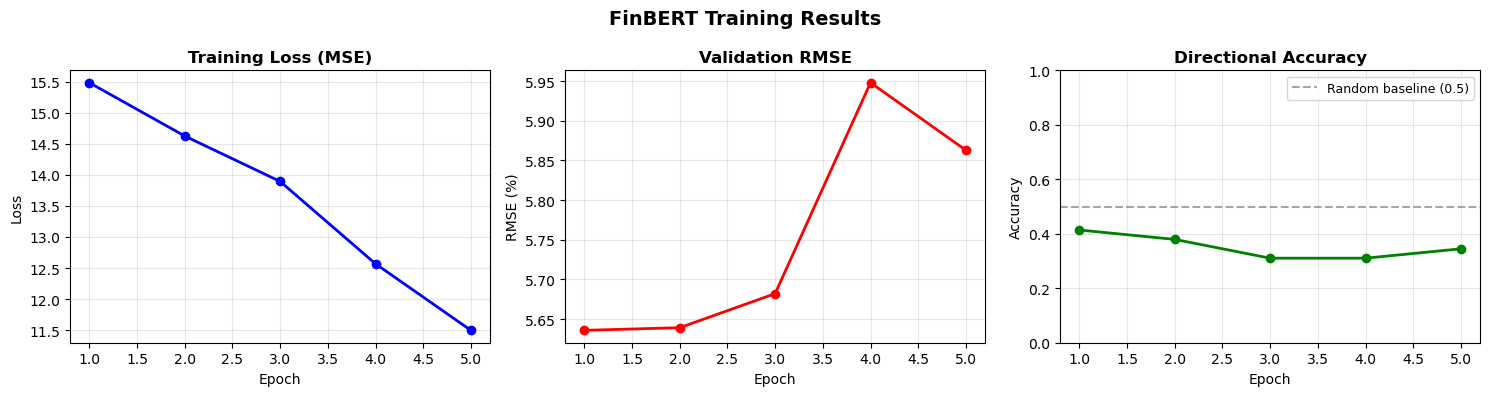

In [9]:
epochs = list(range(1, EPOCHS + 1))
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs, train_losses, 'b-o', linewidth=2, markersize=6)
axes[0].set_title('Training Loss (MSE)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, val_rmses, 'r-o', linewidth=2, markersize=6)
axes[1].set_title('Validation RMSE', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('RMSE (%)')
axes[1].grid(alpha=0.3)

axes[2].plot(epochs, dir_accs, 'g-o', linewidth=2, markersize=6)
axes[2].axhline(0.5, color='gray', linestyle='--', alpha=0.7, label='Random baseline (0.5)')
axes[2].set_title('Directional Accuracy', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy')
axes[2].legend(fontsize=9)
axes[2].set_ylim(0, 1)
axes[2].grid(alpha=0.3)

plt.suptitle('FinBERT Training Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        preds = model(input_ids, attention_mask)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch['label'].numpy())

THRESHOLD = 3.0

def signal(return_pct, threshold=THRESHOLD):
    if return_pct > threshold: return 'BUY'
    elif return_pct < -threshold: return 'SELL'
    return 'HOLD'

print('{:>10} {:>10} {:>10}'.format('Predicted', 'Actual', 'Correct?'))
print('-' * 55)
correct = 0
for pred, actual in zip(all_preds, all_labels):
    pred_sig = signal(pred)
    actual_sig = signal(actual)
    match = '✓' if pred_sig == actual_sig else '✗'
    if pred_sig == actual_sig: correct += 1
    print(f'{pred:>10.2f}% {actual:>10.2f}% {pred_sig:>8} {match:>10}')

print(f'\nSignal Accuracy (±{THRESHOLD}%): {correct}/{len(all_preds)} = {correct/len(all_preds):.2f}')

 Predicted     Actual   Correct?
-------------------------------------------------------
     -1.15%       5.45%     HOLD          ✗
      2.48%      -3.66%     HOLD          ✗
     -1.54%       1.45%     HOLD          ✓
     -0.14%      -0.92%     HOLD          ✓
     -0.09%       0.09%     HOLD          ✓
      1.41%      -0.30%     HOLD          ✓
      1.87%      -2.97%     HOLD          ✓
     -0.57%       3.02%     HOLD          ✗
     -0.78%       7.36%     HOLD          ✗
      2.99%       8.24%     HOLD          ✗
     -2.15%      -0.48%     HOLD          ✓
     -0.75%       0.40%     HOLD          ✓
      0.27%       2.59%     HOLD          ✓
     -0.54%      21.51%     HOLD          ✗
     -1.07%      -1.01%     HOLD          ✓
     -0.98%      -1.67%     HOLD          ✓
     -0.69%       3.61%     HOLD          ✗
      1.00%      -0.10%     HOLD          ✓
     -1.11%      -6.00%     HOLD          ✗
     -1.26%       1.91%     HOLD          ✓
     -1.11%       2.03%     HOL

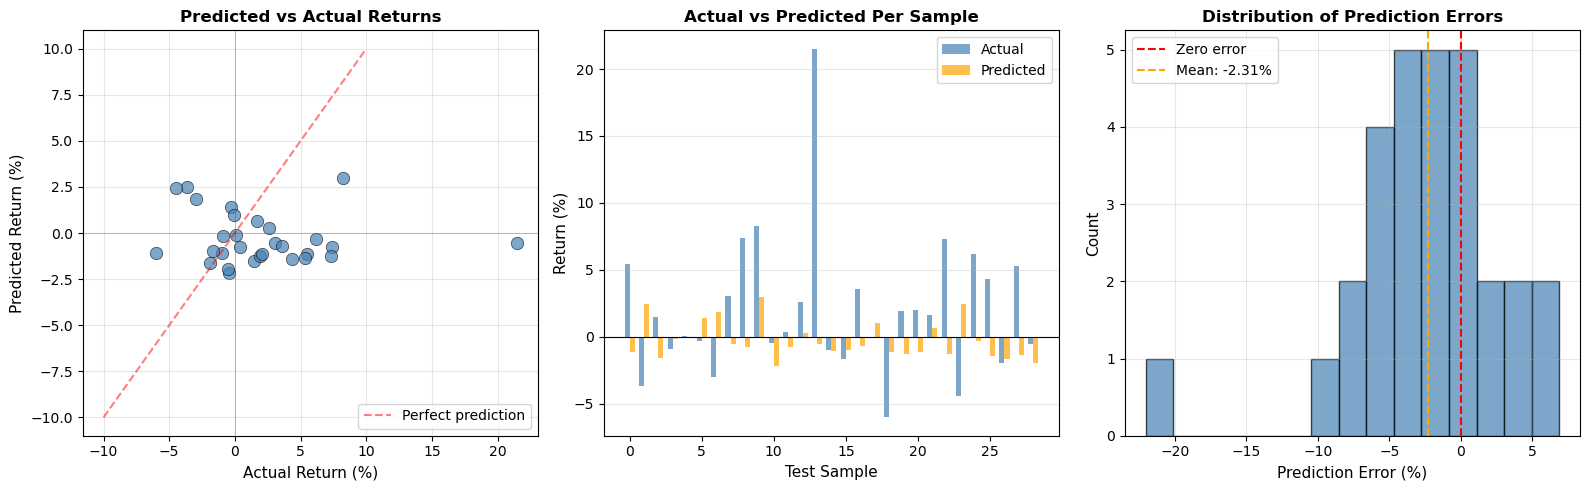

MAE:  4.20%
RMSE: 5.95%
Bias: -2.31%


In [11]:
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
errors = all_preds - all_labels

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Predicted vs Actual
axes[0].scatter(all_labels, all_preds, alpha=0.7, color='steelblue', s=80, edgecolors='black', linewidth=0.5)
axes[0].plot([-10, 10], [-10, 10], 'r--', alpha=0.5, label='Perfect prediction')
axes[0].axhline(0, color='black', linewidth=0.5, alpha=0.3)
axes[0].axvline(0, color='black', linewidth=0.5, alpha=0.3)
axes[0].set_xlabel('Actual Return (%)', fontsize=11)
axes[0].set_ylabel('Predicted Return (%)', fontsize=11)
axes[0].set_title('Predicted vs Actual Returns', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Plot 2: Side by side bar
x = np.arange(len(all_labels))
width = 0.35
axes[1].bar(x - width/2, all_labels, width, label='Actual', color='steelblue', alpha=0.7)
axes[1].bar(x + width/2, all_preds, width, label='Predicted', color='orange', alpha=0.7)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Test Sample', fontsize=11)
axes[1].set_ylabel('Return (%)', fontsize=11)
axes[1].set_title('Actual vs Predicted Per Sample', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')

# Plot 3: Error distribution
axes[2].hist(errors, bins=15, color='steelblue', alpha=0.7, edgecolor='black')
axes[2].axvline(0, color='red', linestyle='--', label='Zero error')
axes[2].axvline(np.mean(errors), color='orange', linestyle='--', label=f'Mean: {np.mean(errors):.2f}%')
axes[2].set_xlabel('Prediction Error (%)', fontsize=11)
axes[2].set_ylabel('Count', fontsize=11)
axes[2].set_title('Distribution of Prediction Errors', fontsize=12, fontweight='bold')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('prediction_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'MAE:  {np.mean(np.abs(errors)):.2f}%')
print(f'RMSE: {np.sqrt(np.mean(errors**2)):.2f}%')
print(f'Bias: {np.mean(errors):.2f}%')

Threshold ±0.5%: 8/29 = 0.28
Threshold ±1.0%: 7/29 = 0.24
Threshold ±1.5%: 8/29 = 0.28
Threshold ±2.0%: 13/29 = 0.45
Threshold ±2.5%: 15/29 = 0.52
Threshold ±3.0%: 16/29 = 0.55


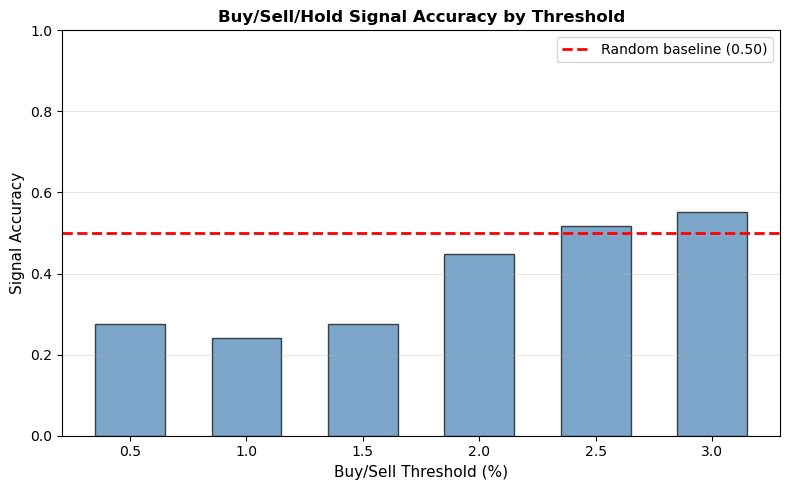

In [12]:
thresholds = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
accuracies = []
for t in thresholds:
    correct = sum(1 for p, a in zip(all_preds, all_labels)
                  if signal(p, t) == signal(a, t))
    accuracies.append(correct / len(all_preds))
    print(f'Threshold ±{t}%: {correct}/{len(all_preds)} = {correct/len(all_preds):.2f}')

plt.figure(figsize=(8, 5))
plt.bar(thresholds, accuracies, color='steelblue', alpha=0.7, width=0.3, edgecolor='black')
plt.axhline(0.5, color='red', linestyle='--', linewidth=2, label='Random baseline (0.50)')
plt.xlabel('Buy/Sell Threshold (%)', fontsize=11)
plt.ylabel('Signal Accuracy', fontsize=11)
plt.title('Buy/Sell/Hold Signal Accuracy by Threshold', fontsize=12, fontweight='bold')
plt.legend(fontsize=10)
plt.ylim(0, 1)
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('signal_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
print('='*50)
print('MODEL SUMMARY')
print('='*50)
print(f'Training samples:     {n_train}')
print(f'Test samples:         {n_test}')
print(f'Final Train Loss:     {train_losses[-1]:.4f}')
print(f'Final Val RMSE:       {val_rmses[-1]:.4f}%')
print(f'Final Dir Accuracy:   {dir_accs[-1]:.2f}')
print(f'MAE:                  {np.mean(np.abs(errors)):.2f}%')
print(f'Best Signal Accuracy: {max(accuracies):.2f} at ±{thresholds[np.argmax(accuracies)]}%')
print('='*50)

MODEL SUMMARY
Training samples:     119
Test samples:         29
Final Train Loss:     11.4958
Final Val RMSE:       5.8629%
Final Dir Accuracy:   0.34
MAE:                  4.20%
Best Signal Accuracy: 0.55 at ±3.0%
